In [ ]:
using LinearAlgebra
using NonlinearEigenproblems
using Plots

In [61]:
N = 99
θ = range(0,length=N+1,stop=pi)
x = reshape(-cos.(θ), N+1, 1)
c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
X = repeat(x, 1, N+1);
dX = X - X';
D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
D = D - diagm(vec(sum(D, dims=2)));
D2 = D^2
D4 = D^4

100×100 Matrix{Float64}:
  9.75254e12  -1.78632e13   1.39939e13  …   3.58237e10  -1.79073e10
  6.1274e12   -1.10705e13   8.34104e12      1.70101e10  -8.50291e9
  1.10291e12  -1.79983e12   9.57414e11     -7.1769e8     3.58755e8
 -1.1658e11    2.70128e11  -2.95365e11      1.28812e8   -6.43899e7
  2.20353e10  -4.86577e10   6.69191e10     -3.92012e7    1.95957e7
 -5.94874e9    1.27226e10  -1.57867e10  …   1.57059e7   -7.85099e6
  2.02937e9   -4.25755e9    4.95356e9      -7.45255e6    3.72537e6
 -8.16083e8    1.69146e9   -1.89106e9       3.96568e6   -1.98236e6
  3.70672e8   -7.6209e8     8.30123e8      -2.29185e6    1.14565e6
 -1.8491e8     3.78037e8   -4.0449e8        1.40929e6   -7.0448e5
  ⋮                                     ⋱               
  1.14565e6   -2.29185e6    2.29348e6      -7.6209e8     3.70672e8
 -1.98236e6    3.96568e6   -3.96855e6       1.69146e9   -8.16083e8
  3.72537e6   -7.45255e6    7.45802e6      -4.25755e9    2.02937e9
 -7.85099e6    1.57059e7   -1.57175e7       1.2

In [ ]:
U   = 1 .-yF.^2;
Up  = -2*yF;
Upp = -2;

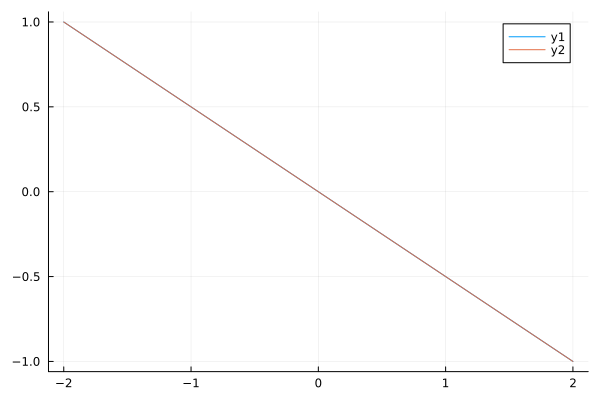

In [67]:
plot(Up,x)
plot!(D*U,x)

In [ ]:
Re = 2000;    # Reynolds number
ω  = 0.3;     # Input frequency
β  = 0.0;     # Spanwise wavenumber

In [ ]:
yF = x
# The base flow for Poiseuille plane flow
U   = 1 .-yF.^2;
Up  = -2*yF;
Upp = -2;

eye = Matrix{Float64}(I, N+1, N+1);  

In [ ]:
A4 = [-eye/Re zeros(N+1,N+1); zeros(N+1,N+1) zeros(N+1,N+1)];
A3 = [-1im*U.* I(N+1) zeros(N+1,N+1); zeros(N+1,N+1) zeros(N+1,N+1)];
A2 = [(1im*ω-2β^2/Re)*eye+2D2/Re zeros(N+1,N+1);zeros(N+1,N+1) eye/Re];
A1 = [1im*(U.* I(N+1)*(D2-eye*β^2)-Upp*eye) zeros(N+1,N+1);zeros(N+1,N+1) 1im*U.* I(N+1)];
A0 = [2β^2*D2/Re-D4/Re-β^4*eye/Re+1im*ω*(β^2*eye-D2) zeros(N+1,N+1);1im*β*Up.* I(N+1) (-1im*ω+β^2/Re)*eye-D2/Re];
nep = PEP([A0,A1,A,2A3,A4]); #Create a PEP object

In [ ]:
sc=100;
nep1 = shift_and_scale(nep,scale=sc);
mult_scale = norm(nep1.A[end]);
nep2 = PEP(nep1.A ./ mult_scale);
λ1,v1 = tiar(nep2,σ=0.006,v=ones(size(nep,1)),neigs=10,maxit=200,tol=1e-14);
λ2,v2 = tiar(nep2,σ=0.005+0.005im,v=ones(size(nep,1)),neigs=10,maxit=200,tol=1e-14);
λtotal = [λ1;λ2];

In [ ]:
λ_orig = sc*λtotal

In [ ]:
plot(real.(λ_orig),imag.(λ_orig),seriestype=:scatter,xaxis=[0.2,1.05],yaxis=[0,0.8])

In [78]:
using LinearAlgebra

"""
构建切比雪夫微分矩阵 (Chebyshev Differentiation Matrix)
N: 多项式阶数
"""
function cheby_diff(N)
    if N == 0 return [0.0], [1.0] end
    # Gauss-Lobatto 节点 [cite: 202, 212]
    y = cos.(pi .* (0:N) ./ N)
    c = [2.0; ones(N-1); 2.0] .* (-1).^(0:N)
    X = repeat(y, 1, N+1)
    dX = X - X'
    D = (c * (1.0 ./ c)') ./ (dX + I)
    D -= diagm(sum(D, dims=2)[:])
    return D, y
end

"""
求解 Orr-Sommerfeld 特征值问题
"""
function solve_os(Re, alpha, N)
    D1, y = cheby_diff(N)
    D2 = D1^2
    D4 = D2^2
    
    I_mat = I(N+1)
    # 基本流 Poiseuille: U = 1 - y^2
    U = diagm(1.0 .- y.^2)
    Upp = diagm(fill(-2.0, N+1))
    
    # 构建算子矩阵
    # L = i*alpha*U*(D^2 - alpha^2) - i*alpha*U'' - (D^2 - alpha^2)^2 / Re
    k2 = alpha^2
    OS = (im * alpha) .* (U * (D2 - k2 * I_mat) - Upp) .- (D4 - 2*k2*D2 + k2^2 * I_mat) ./ Re
    B = (im) .* (D2 - k2 * I_mat)
    
    # 应用边界条件: phi = phi' = 0 在 y = +/- 1
    # 做法：剔除矩阵的第一、二行/列和最后两行/列 
    indices = 3:N-1
    OS_bc = OS[indices, indices]
    B_bc = B[indices, indices]
    
    # 求解广义特征值问题 
    evals = eigen(OS_bc, B_bc).values
    
    # 转换回 c = omega / alpha
    return evals
end

# 参数设置
Re = 5772.5    # 临界雷诺数附近
alpha = 1.04   # 临界波数
N_cheb = 99        # 切比雪夫模态数

eigenvalues = solve_os(Re, alpha, N_cheb)

# 找到虚部最大的特征值（增长率最高的模态）
max_growth = maximum(imag.(eigenvalues))
println("最大增长率 (imag(c)): ", max_growth)

最大增长率 (imag(c)): -7.562873035868683e-5


In [88]:
data_all = [0 0 0]
for alpha = 0.5 : 0.01 : 1.5
    for Re = 5000 : 100 : 10000
        eigenvalues = solve_os(Re, alpha, N_cheb)
        max_growth = maximum(imag.(eigenvalues))
        data = [Re alpha max_growth]
        data_all = [data_all;data]
        writedlm("Dataall.dat",data_all)
    end
end

In [ ]:
using DelimitedFiles
data_all = [0 0 0]
data = [Re alpha max_growth]
data_all = [data_all;data]
writedlm("Dataall.dat",data_all)

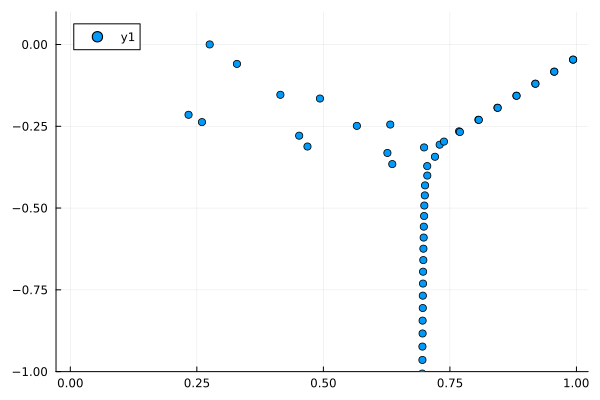

In [76]:
scatter(real.(eigenvalues),imag.(eigenvalues),ylims=[-1,0.1])